In [ ]:
# @title 1. Setup & Data Prep
!pip install -q timm  # Required for ViT backbones

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab import drive
import shutil

# --- MOUNT DRIVE & UNZIP ---
# We unzip to /content/dataset which is Colab's ephemeral SSD (much faster than Drive)
if not os.path.exists('/content/dataset'):
    drive.mount('/content/drive')
    print("📦 Unzipping dataset... (This may take 1-2 mins)")
    # UPDATE THIS PATH if your zip is in a subfolder
    !unzip -q "/content/drive/MyDrive/rugd_224_patches.zip" -d "/content/dataset"
    print("✅ Dataset ready at /content/dataset")
else:
    print("✅ Dataset already exists.")

# --- CONFIGURATION ---
DATASET_ROOT = "/content/dataset"
CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Colab T4 Params
BATCH_SIZE = 64          # Increased for Colab (vs 16 on laptop)
NUM_WORKERS = 2
LR = 3e-4
NUM_EPOCHS = 15
NUM_CLASSES = 25         # 0-24 (based on your colormap)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Training Config: Batch={BATCH_SIZE} | Device={DEVICE}")

Mounted at /content/drive
📦 Unzipping dataset... (This may take 1-2 mins)
✅ Dataset ready at /content/dataset
🚀 Training Config: Batch=64 | Device=cpu


In [ ]:
# @title 2. Memory-Efficient Dataset Loader
class RUGD_Patch_Dataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.images_dir = os.path.join(root_dir, split, 'images')
        self.masks_dir = os.path.join(root_dir, split, 'masks')

        # Filter for valid images
        self.image_files = [f for f in sorted(os.listdir(self.images_dir)) if f.endswith(('.jpg', '.png'))]

        # DINO Standard Normalization (ImageNet stats)
        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        # Mask name logic: matches image name but likely .png
        mask_name = os.path.splitext(img_name)[0] + ".png"

        # Load Image
        img_path = os.path.join(self.images_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load Mask (FLAG_0 ensures 1-channel grayscale reading)
        mask_path = os.path.join(self.masks_dir, mask_name)
        mask = cv2.imread(mask_path, 0)

        if mask is None:
            # Fallback for safety
            mask = np.zeros((224, 224), dtype=np.uint8)

        # Transform
        image = self.normalize(image)
        mask = torch.from_numpy(mask).long()

        return image, mask

# Initialize Loaders
train_ds = RUGD_Patch_Dataset(DATASET_ROOT, split='train')
val_ds = RUGD_Patch_Dataset(DATASET_ROOT, split='val')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"📂 Data Loaded: {len(train_ds)} train patches | {len(val_ds)} val patches")

📂 Data Loaded: 40356 train patches | 4260 val patches


In [ ]:
# @title 3. Model Architecture (Frozen Backbone)
class FrozenBackboneSegmenter(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        print("⬇️ Loading DINOv2-Small Backbone...")
        # We use DINOv2 as the architectural proxy for the DINO family
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

        # 🛑 FREEZE THE BACKBONE (The core of this POC)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Simple Decoder (Linear Probe + Upsampling)
        # ViT-Small embedding dimension is 384
        self.head = nn.Sequential(
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )

    def forward(self, x):
        # 1. Forward Pass through Frozen Backbone
        with torch.no_grad():
            # Extract patch tokens. Shape: [Batch, N_Patches, Dim]
            # For 224x224, N_Patches = (224/14)^2 = 256
            features_dict = self.backbone.forward_features(x)
            patch_tokens = features_dict['x_norm_patchtokens']

        # 2. Reshape Tokens to Spatial Map
        # [B, 256, 384] -> [B, 384, 16, 16]
        B, N, C = patch_tokens.shape
        H = W = int(N**0.5) # 16
        spatial_features = patch_tokens.permute(0, 2, 1).reshape(B, C, H, W)

        # 3. Decode
        logits = self.head(spatial_features)

        # 4. Upsample to match input (224x224)
        logits = F.interpolate(logits, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)

        return logits

model = FrozenBackboneSegmenter(NUM_CLASSES).to(DEVICE)
print("✅ Model Initialized & Backbone Frozen.")

⬇️ Loading DINOv2-Small Backbone...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 308MB/s]


✅ Model Initialized & Backbone Frozen.


In [ ]:
# @title 4. Training Loop
def calculate_miou(preds, masks, num_classes):
    # Simple mIoU calculator for monitoring
    preds = torch.argmax(preds, dim=1).flatten()
    masks = masks.flatten()
    iou_list = []
    for c in range(num_classes):
        # Ignore void class 0 if preferred, but RUGD class 0 is often valid (void/dirt)
        # Here we calculate for all
        match_pred = (preds == c)
        match_gt = (masks == c)
        intersection = (match_pred & match_gt).sum().float()
        union = (match_pred | match_gt).sum().float()

        if union > 0:
            iou_list.append(intersection / union)
    return torch.tensor(iou_list).mean().item()

# Setup Training
optimizer = torch.optim.AdamW(model.head.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss() # Standard CE
scaler = torch.cuda.amp.GradScaler() # Mixed Precision

train_losses, val_mious = [], []

print("🔥 Starting Training...")

for epoch in range(NUM_EPOCHS):
    # --- TRAIN ---
    model.train()
    model.backbone.eval() # Force backbone to eval mode (norms/dropout)

    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- VALIDATION ---
    model.eval()
    miou_accum = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            miou_accum += calculate_miou(outputs, masks, NUM_CLASSES)

    avg_miou = miou_accum / len(val_loader)
    val_mious.append(avg_miou)

    print(f"📊 Epoch {epoch+1} Result: Loss={avg_loss:.4f} | mIoU={avg_miou:.4f}")

    # Save best model
    if epoch > 0 and avg_miou > max(val_mious[:-1]):
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/best_model.pth")
        print("💾 Best Model Saved!")

/tmp/ipython-input-1771168967.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() # Mixed Precision
/usr/local/lib/python3.12/dist-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


🔥 Starting Training...


Epoch 1/15:   0%|          | 0/631 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-1771168967.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch 1/15:   0%|          | 3/631 [01:27<5:06:31, 29.29s/it, loss=2.0207]


KeyboardInterrupt: 

🎨 Visualizing Random Predictions...


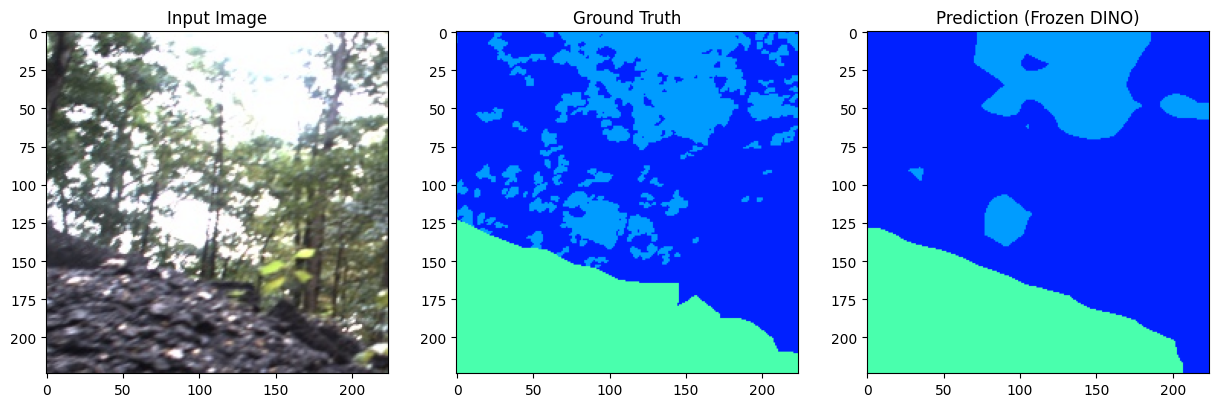

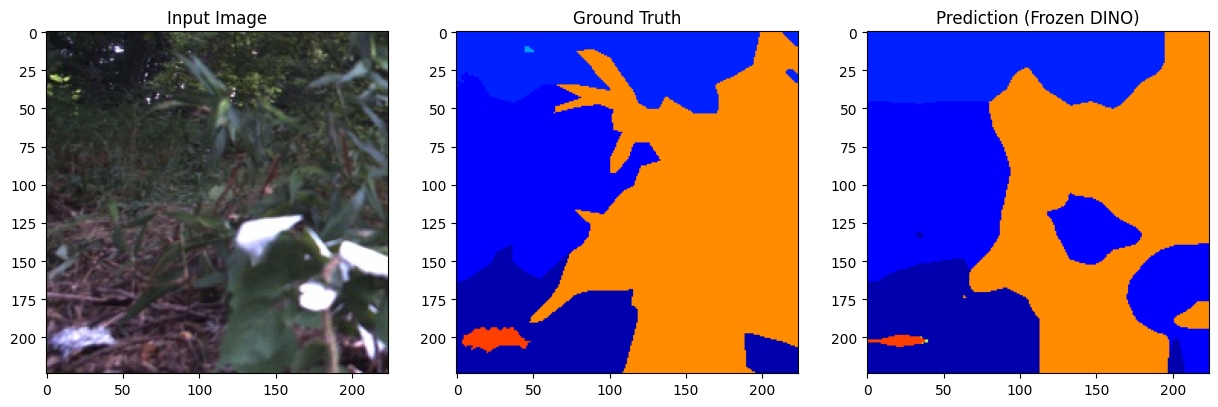

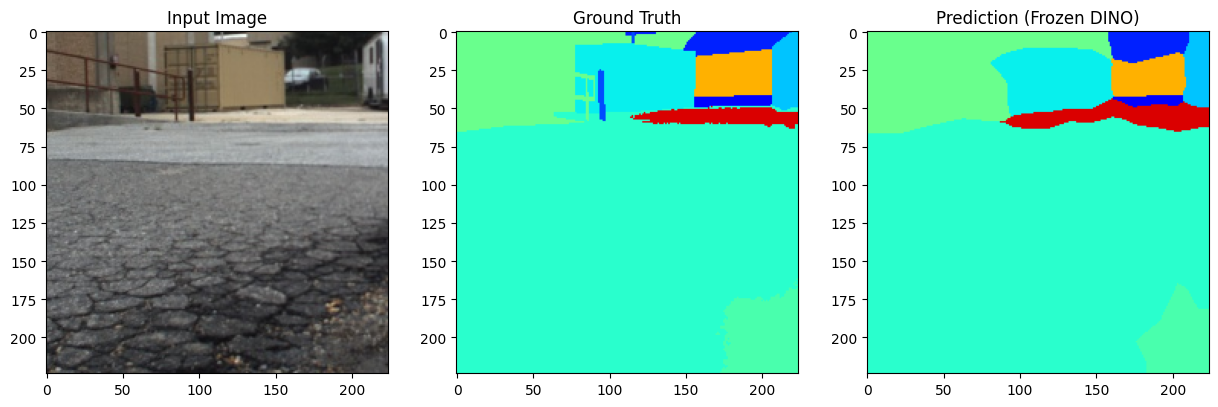

In [ ]:
# @title 5. Visualize Results
def visualize_prediction(dataset, model, index=None):
    model.eval()
    if index is None:
        index = np.random.randint(0, len(dataset))

    image, mask = dataset[index]
    input_tensor = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    # Denormalize image for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    disp_img = image.permute(1, 2, 0).numpy() * std + mean
    disp_img = np.clip(disp_img, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(disp_img)
    ax[0].set_title("Input Image")
    ax[1].imshow(mask, cmap='jet', vmin=0, vmax=NUM_CLASSES)
    ax[1].set_title("Ground Truth")
    ax[2].imshow(pred_mask, cmap='jet', vmin=0, vmax=NUM_CLASSES)
    ax[2].set_title(f"Prediction (Frozen DINO)")
    plt.show()

# Show 3 random examples
print("🎨 Visualizing Random Predictions...")
for _ in range(3):
    visualize_prediction(val_ds, model)

⚡ Running Inference at 448x448 (Grid: 32x32)...


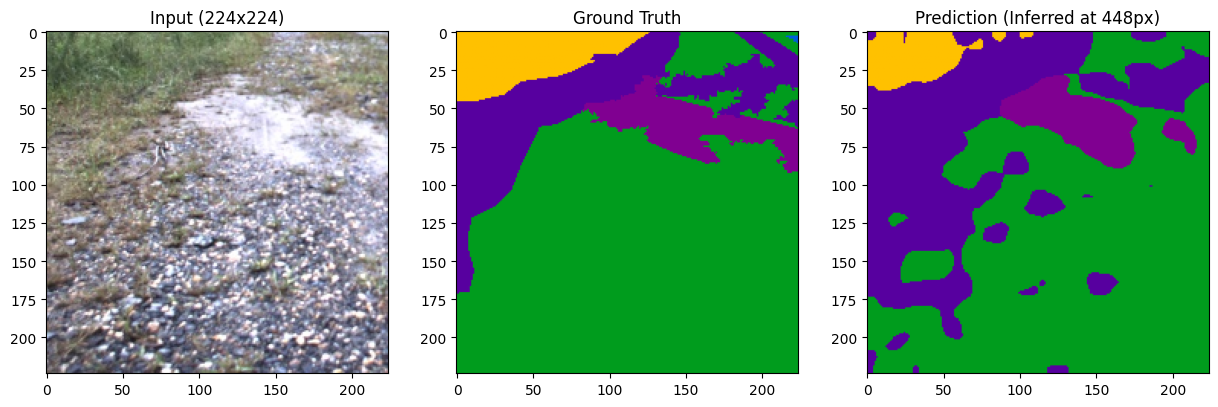

In [ ]:
# @title 🔭 High-Res Inference Test
def visualize_high_res(dataset, model, index=None, resolution=448):
    model.eval()
    if index is None:
        index = np.random.randint(0, len(dataset))

    # 1. Load original 224 data
    image_small, mask = dataset[index]

    # 2. Create a High-Res Input (Resize strictly for inference)
    # We use the original image tensor but resize it up
    transform_high_res = transforms.Compose([
        transforms.Resize((resolution, resolution), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # We need to get the raw un-normalized image first to resize cleanly
    # So we undo the dataset normalization roughly or reload raw
    # Quick hack: Just resize the tensor (it works for a test)
    input_high_res = F.interpolate(image_small.unsqueeze(0), size=(resolution, resolution), mode='bicubic')
    input_high_res = input_high_res.to(DEVICE)

    print(f"⚡ Running Inference at {resolution}x{resolution} (Grid: {resolution//14}x{resolution//14})...")

    with torch.no_grad():
        # DINOv2 automatically handles larger inputs by interpolating position embeddings
        output = model(input_high_res)

        # Output is now 448x448, resize back to 224x224 to compare with Ground Truth
        output_small = F.interpolate(output, size=(224, 224), mode='bilinear', align_corners=False)
        pred_mask = torch.argmax(output_small, dim=1).squeeze(0).cpu().numpy()

    # Display
    # Denormalize small image for plotting
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    disp_img = image_small.permute(1, 2, 0).numpy() * std + mean
    disp_img = np.clip(disp_img, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(disp_img)
    ax[0].set_title("Input (224x224)")

    ax[1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=NUM_CLASSES)
    ax[1].set_title("Ground Truth")

    ax[2].imshow(pred_mask, cmap='nipy_spectral', vmin=0, vmax=NUM_CLASSES)
    ax[2].set_title(f"Prediction (Inferred at {resolution}px)")
    plt.show()

# Try running it!
visualize_high_res(val_ds, model, resolution=448) # Try 448 or 518

In [ ]:
# @title 🚀 Project 4: Fine-Tuning the Backbone (Unfreeze Last Blocks)
# Load the best checkpoint from the previous run
CHECKPOINT_PATH = "/content/checkpoints/best_model.pth"
model.load_state_dict(torch.load(CHECKPOINT_PATH))
print(f"📥 Loaded Best Model from Epoch {torch.load(CHECKPOINT_PATH).get('epoch', 'Unknown')}")

# --- STRATEGY: UNFREEZE LAST 4 BLOCKS ---
# DINOv2 ViT-Small usually has 12 blocks. We unfreeze 8, 9, 10, 11.
print("🔓 Unfreezing last 4 backbone blocks...")

# 1. Unfreeze specific blocks
# The backbone structure is usually: backbone.blocks[i]
for i, block in enumerate(model.backbone.blocks):
    if i >= 8:  # Unfreeze block 8, 9, 10, 11
        for param in block.parameters():
            param.requires_grad = True
    else:
        # Keep 0-7 frozen
        for param in block.parameters():
            param.requires_grad = False

# 2. Unfreeze Norm Layers (Always good for domain adaptation)
for param in model.backbone.norm.parameters():
    param.requires_grad = True

# Verify Trainable Parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"📊 Trainable Parameters: {trainable_params/1e6:.2f}M / {total_params/1e6:.2f}M")

# --- CONFIGURATION FOR FINE-TUNING ---
# CRITICAL: Use a much lower Learning Rate for the backbone to prevent "feature collapse"
FT_LR = 1e-5  # 10x smaller than previous (1e-4)
FT_EPOCHS = 10

# Differential Learning Rate (Optional but recommended)
# Head gets higher LR, Backbone gets lower LR
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5}, # Low LR for backbone
    {'params': model.head.parameters(), 'lr': 1e-4}      # Keep original LR for head
])

criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler()

print("🔥 Starting Fine-Tuning Phase...")

# --- REUSE TRAINING LOOP ---
# (We reuse the exact same loop code from before, just running it again)
fine_tune_losses, fine_tune_mious = [], []

for epoch in range(FT_EPOCHS):
    model.train()
    # Note: We strictly keep BatchNorm in eval mode if using a small batch size,
    # but ViT uses LayerNorm which works fine in train mode.

    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Fine-Tune Epoch {epoch+1}/{FT_EPOCHS}")

    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_loss = epoch_loss / len(train_loader)
    fine_tune_losses.append(avg_loss)

    # Validation
    model.eval()
    miou_accum = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            miou_accum += calculate_miou(outputs, masks, NUM_CLASSES)

    avg_miou = miou_accum / len(val_loader)
    fine_tune_mious.append(avg_miou)

    print(f"📈 FT Epoch {epoch+1} Result: Loss={avg_loss:.4f} | mIoU={avg_miou:.4f}")

    if epoch > 0 and avg_miou > max(fine_tune_mious[:-1]):
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/best_model_finetuned.pth")
        print("💾 Best Fine-Tuned Model Saved!")

/tmp/ipython-input-2164809500.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


📥 Loaded Best Model from Epoch Unknown
🔓 Unfreezing last 4 backbone blocks...
📊 Trainable Parameters: 7.99M / 22.95M
🔥 Starting Fine-Tuning Phase...


Fine-Tune Epoch 1/10:   0%|          | 0/631 [00:00<?, ?it/s]/tmp/ipython-input-2164809500.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fine-Tune Epoch 1/10: 100%|██████████| 631/631 [02:21<00:00,  4.45it/s, loss=0.2293]


📈 FT Epoch 1 Result: Loss=0.2174 | mIoU=0.4348


Fine-Tune Epoch 2/10: 100%|██████████| 631/631 [02:21<00:00,  4.46it/s, loss=0.1976]


...

📈 FT Epoch 3 Result: Loss=0.2140 | mIoU=0.4315


Fine-Tune Epoch 4/10: 100%|██████████| 631/631 [02:21<00:00,  4.45it/s, loss=0.2100]


📈 FT Epoch 4 Result: Loss=0.2128 | mIoU=0.4253


Fine-Tune Epoch 5/10:  34%|███▎      | 212/631 [00:49<01:38,  4.25it/s, loss=0.2234]


KeyboardInterrupt: 

# DinoV2 Base

In [ ]:
# @title 🚀 Upgrade to DINOv2-Base (Better Usage, Better Results)

# 1. CONFIGURATION UPDATES
# We increase batch size because we have room, but Base is heavier than Small
BATCH_SIZE = 256        # Safe start for Base model (Adjust to 64 if no OOM)
LR = 2e-4              # Slightly lower LR for larger model
NUM_EPOCHS = 15
EMBED_DIM = 768        # Base model has 768 dim (Small was 384)

print(f"🚀 Switching to ViT-Base | Batch Size: {BATCH_SIZE}")

# 2. DEFINE BASE MODEL
class ViTBaseSegmenter(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        print("⬇️ Loading DINOv2-BASE (86M Params)...")
        # CHANGE: 'vitb14' instead of 'vits14'
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

        # Freeze Backbone initially
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Decoder needs to match Embed Dim 768
        self.head = nn.Sequential(
            nn.Conv2d(768, 512, kernel_size=3, padding=1), # 768 input
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, num_classes, kernel_size=1)
        )

    def forward(self, x):
        with torch.no_grad():
            features_dict = self.backbone.forward_features(x)
            patch_tokens = features_dict['x_norm_patchtokens']

        # Reshape
        B, N, C = patch_tokens.shape
        H = W = int(N**0.5)
        spatial_features = patch_tokens.permute(0, 2, 1).reshape(B, C, H, W)

        logits = self.head(spatial_features)
        logits = F.interpolate(logits, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)
        return logits

# 3. RE-INITIALIZE
model = ViTBaseSegmenter(NUM_CLASSES).to(DEVICE)
optimizer = torch.optim.AdamW(model.head.parameters(), lr=LR)
scaler = torch.cuda.amp.GradScaler()

print("✅ Model Upgraded to DINOv2-Base.")

🚀 Switching to ViT-Base | Batch Size: 256
⬇️ Loading DINOv2-BASE (86M Params)...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Model Upgraded to DINOv2-Base.


/tmp/ipython-input-474578484.py:50: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
BATCH_SIZE = 256

In [ ]:
# @title 🚀 Phase 2: Full Fine-Tuning (ViT-Base)
# This unfreezes the backbone to maximize mIoU

# --- CONFIGURATION ---
# We MUST lower the batch size because unfreezing stores huge gradients
FT_BATCH_SIZE = 32      # Safe starting point for Unfrozen Base (Try 48 if 32 works)
FT_EPOCHS = 15
BACKBONE_LR = 5e-6      # Very low to preserve DINO knowledge
HEAD_LR = 5e-4          # High to learn RUGD classes fast

print(f"🔓 Unfreezing ViT-Base Backbone | Batch: {FT_BATCH_SIZE}")

# 1. Re-create Loaders with smaller batch size (to prevent OOM)
train_loader_ft = DataLoader(train_ds, batch_size=FT_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_ft = DataLoader(val_ds, batch_size=FT_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 2. Unfreeze EVERYTHING
for param in model.backbone.parameters():
    param.requires_grad = True

# 3. Differential Optimizer (Crucial for Stability)
optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': BACKBONE_LR}, # 5e-6
    {'params': model.head.parameters(), 'lr': HEAD_LR}          # 5e-4
], weight_decay=0.01)

scaler = torch.cuda.amp.GradScaler()
criterion = nn.CrossEntropyLoss()

# 4. Training Loop (Fine-Tuning)
ft_losses, ft_mious = [], []
best_ft_miou = 0.0

print("🔥 Starting End-to-End Fine-Tuning...")

for epoch in range(FT_EPOCHS):
    model.train()
    # Optional: Keep Norm layers in eval to stabilize training if batch is small
    # model.backbone.eval()

    epoch_loss = 0
    pbar = tqdm(train_loader_ft, desc=f"Fine-Tune Epoch {epoch+1}/{FT_EPOCHS}")

    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_loss = epoch_loss / len(train_loader_ft)
    ft_losses.append(avg_loss)

    # Validation
    model.eval()
    miou_accum = 0
    with torch.no_grad():
        for images, masks in val_loader_ft:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            miou_accum += calculate_miou(outputs, masks, NUM_CLASSES)

    avg_miou = miou_accum / len(val_loader_ft)
    ft_mious.append(avg_miou)

    print(f"📈 FT Epoch {epoch+1} Result: Loss={avg_loss:.4f} | mIoU={avg_miou:.4f}")

    if avg_miou > best_ft_miou:
        best_ft_miou = avg_miou
        torch.save(model.state_dict(), f"{BASE_CHECKPOINT_DIR}/best_model_base_finetuned.pth")
        print("💾 Best Fine-Tuned Model Saved!")

print(f"\n🏆 Fine-Tuning Complete. Top mIoU: {best_ft_miou:.4f}")

/tmp/ipython-input-3778790418.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🔓 Unfreezing ViT-Base Backbone | Batch: 32
🔥 Starting End-to-End Fine-Tuning...


Fine-Tune Epoch 1/15:   0%|          | 0/1262 [00:00<?, ?it/s]/tmp/ipython-input-3778790418.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Fine-Tune Epoch 1/15: 100%|██████████| 1262/1262 [03:54<00:00,  5.37it/s, loss=0.3181]


📈 FT Epoch 1 Result: Loss=0.3015 | mIoU=0.4344
💾 Best Fine-Tuned Model Saved!


Fine-Tune Epoch 2/15: 100%|██████████| 1262/1262 [03:56<00:00,  5.33it/s, loss=0.2447]


...

📈 FT Epoch 13 Result: Loss=0.1956 | mIoU=0.4525


Fine-Tune Epoch 14/15: 100%|██████████| 1262/1262 [03:57<00:00,  5.31it/s, loss=0.1806]


📈 FT Epoch 14 Result: Loss=0.1928 | mIoU=0.4502


Fine-Tune Epoch 15/15: 100%|██████████| 1262/1262 [03:57<00:00,  5.31it/s, loss=0.2539]


📈 FT Epoch 15 Result: Loss=0.1894 | mIoU=0.4509

🏆 Fine-Tuning Complete. Top mIoU: 0.4628
